In [5]:
# === Imports & All Definitions (no execution) ===
import os, argparse
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import erf
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

# ---------- Utilities ----------
def ensure_dir(path): os.makedirs(path, exist_ok=True)

def cpm_log(df: pd.DataFrame, sample_cols):
    lib_sizes = df[sample_cols].sum(axis=0)
    cpm = df[sample_cols].divide(lib_sizes, axis=1) * 1e6
    return np.log2(cpm + 1)

def z2p(z):  # two-sided normal
    return 2 * (1 - 0.5 * (1 + erf(abs(z)/np.sqrt(2))))

def bh_fdr(pvals):
    p = np.array(pvals); n = len(p); idx = np.argsort(p); ranked = p[idx]
    q = np.empty(n, float); prev = 1.0
    for i in range(n-1, -1, -1):
        q_i = ranked[i] * n / (i+1); prev = min(prev, q_i); q[i] = prev
    out = np.empty(n, float); out[idx] = q; return out

def zscore(x):
    x = np.asarray(x, float); return (x - x.mean()) / (x.std(ddof=1) + 1e-8)

# ---------- Counterfactual models ----------
def svd_feature_impute(Y, F, F_target, rank=2):
    col_mean = Y.mean(axis=0, keepdims=True); Yc = Y - col_mean
    U, s, VT = np.linalg.svd(Yc, full_matrices=False)
    U_k, S_k, V_k = U[:, :rank], np.diag(s[:rank]), VT[:rank, :].T
    Z = V_k @ S_k
    alpha = 1.0
    W = np.linalg.solve(F.T @ F + alpha*np.eye(F.shape[1]), F.T @ Z)
    Z_star = F_target @ W
    Y_star = U_k @ S_k @ Z_star.T
    col_mean_star = col_mean.mean(axis=1, keepdims=True)
    return (Y_star + col_mean_star).ravel()

def ridge_per_gene(Y, F, F_target, alpha=0.1):
    inv = np.linalg.inv(F.T @ F + alpha*np.eye(F.shape[1]))
    coefs = (inv @ F.T) @ Y.T   # P x G
    return (F_target @ coefs).ravel()

def loco_cv_svd(Y, F, ranks=(1,2,3)):
    out = {}
    for r in ranks:
        errs = []
        for i in range(F.shape[0]):
            keep = [j for j in range(F.shape[0]) if j != i]
            yhat = svd_feature_impute(Y[:, keep], F[keep, :], F[i:i+1, :], rank=r)
            errs.append(np.sqrt(np.mean((Y[:, i] - yhat)**2)))
        out[r] = float(np.mean(errs))
    return out

def loco_cv_ridge(Y, F, alphas=(0.1, 1.0, 10.0)):
    out = {}
    for a in alphas:
        errs = []
        for i in range(F.shape[0]):
            keep = [j for j in range(F.shape[0]) if j != i]
            yhat = ridge_per_gene(Y[:, keep], F[keep, :], F[i:i+1, :], alpha=a)
            errs.append(np.sqrt(np.mean((Y[:, i] - yhat)**2)))
        out[a] = float(np.mean(errs))
    return out

# ---------- Figures ----------
def plot_model_selection(svd_rmse, ridge_rmse, outpng):
    plt.figure()
    plt.plot(list(svd_rmse.keys()), list(svd_rmse.values()), marker="o", label="SVD rank")
    plt.plot(list(ridge_rmse.keys()), list(ridge_rmse.values()), marker="o", label="Ridge alpha")
    plt.xlabel("Hyperparameter"); plt.ylabel("LOCO-CV RMSE"); plt.title("Model selection")
    plt.legend(); plt.tight_layout(); plt.savefig(outpng, dpi=300); plt.close()

def plot_agreement(pred_a, pred_b, outpng):
    plt.figure()
    plt.scatter(pred_a, pred_b, s=5, alpha=0.4)
    plt.xlabel("Pred KO-Latent (SVD)"); plt.ylabel("Pred KO-Latent (Ridge)")
    plt.title("Prediction agreement"); plt.tight_layout(); plt.savefig(outpng, dpi=300); plt.close()

def plot_fail_hist(fail_vals, method, outpng):
    plt.figure()
    plt.hist(fail_vals, bins=60, alpha=0.8)
    plt.xlabel("Fail = WT-Latent - Pred KO-Latent"); plt.ylabel("Gene count")
    plt.title(f"Fail distribution ({method})"); plt.tight_layout(); plt.savefig(outpng, dpi=300); plt.close()

def volcano(effect, qvals, genes, chip_hits, title, outpng, topn=15):
    x = effect; y = -np.log10(qvals + 1e-300)
    plt.figure(figsize=(6,4))
    plt.scatter(x, y, s=6, alpha=0.5)
    mask_sig = qvals < 0.05
    plt.scatter(x[mask_sig], y[mask_sig], s=8, alpha=0.7)
    if chip_hits is not None and np.sum(chip_hits)>0:
        plt.scatter(x[chip_hits==1], y[chip_hits==1], s=10, alpha=0.8, marker="x")
    top_idx = np.argsort(-y)[:topn]
    for i in top_idx:
        if y[i] > np.percentile(y, 95):
            plt.text(x[i], y[i], genes[i], fontsize=7)
    plt.axhline(-np.log10(0.05), ls="--", lw=1)
    plt.xlabel("Effect size"); plt.ylabel("-log10(FDR)"); plt.title(title)
    plt.tight_layout(); plt.savefig(outpng, dpi=300); plt.close()

def plot_heatmap_top(expr_mat, row_names, col_names, outpng):
    expr = (expr_mat - expr_mat.mean(axis=1, keepdims=True)) / (expr_mat.std(axis=1, ddof=1, keepdims=True)+1e-8)
    plt.figure(figsize=(7, max(6, 0.16*expr.shape[0])))
    plt.imshow(expr, aspect="auto"); plt.colorbar(label="Row z-score")
    plt.yticks(range(expr.shape[0]), row_names, fontsize=6)
    plt.xticks(range(expr.shape[1]), col_names, rotation=45)
    plt.title("Top genes by composite Score"); plt.tight_layout(); plt.savefig(outpng, dpi=300); plt.close()

def plot_modules_heatmap(me_cond, labels, cond_order, outpng):
    plt.figure(figsize=(7, max(4, len(labels)*0.25)))
    plt.imshow(me_cond, aspect="auto"); plt.colorbar(label="Module eigengene (mean per condition)")
    plt.yticks(range(len(labels)), [f"Module {m}" for m in labels], fontsize=7)
    plt.xticks(range(len(cond_order)), cond_order, rotation=45)
    plt.title("Module eigengenes across conditions"); plt.tight_layout(); plt.savefig(outpng, dpi=300); plt.close()

def plot_module_scores(labels, mod_scores, outpng):
    plt.figure(figsize=(6,3.5))
    plt.bar([f"M{m}" for m in labels], mod_scores)
    plt.ylabel("Mean composite Score"); plt.title("Module priority by composite Score")
    plt.tight_layout(); plt.savefig(outpng, dpi=300); plt.close()

# ---------- Pipeline ----------
def run_pipeline(input_csv, outdir="napm_results", chip_txt=None):
    ensure_dir(outdir)
    df = pd.read_csv(input_csv)

    cond_map = {
        "WT": ["WT-rep1", "WT-rep2"],
        "WT-Hypoxia": ["Hypoxia-rep1", "Hypoxia-rep2"],
        "WT-Latent": ["Latent-rep1", "Latent-rep2"],
        "KO": ["NapM-KO-rep1", "NapM-KO-rep2"],
        "KO-Hypoxia": ["NapM_Ko-Hypoxia-rep1", "NapM_Ko-Hypoxia-rep2"],
    }
    needed = ["gene"] + sum(cond_map.values(), [])
    for c in needed:
        if c not in df.columns:
            raise ValueError(f"Missing column: {c}")

    # replicate-level logCPM
    logcpm_rep = cpm_log(df, sum(cond_map.values(), []))
    logcpm_rep.insert(0, "gene", df["gene"])

    # condition means
    logcpm_cond = {"gene": df["gene"]}
    for cond, reps in cond_map.items():
        logcpm_cond[cond] = logcpm_rep[reps].mean(axis=1)
    logcpm_cond = pd.DataFrame(logcpm_cond)

    conds = ["WT", "WT-Hypoxia", "WT-Latent", "KO", "KO-Hypoxia"]
    genes = logcpm_cond["gene"].tolist()
    Y = logcpm_cond[conds].values

    # feature matrix
    feat_rows = {
        "WT":            [1, 1, 0, 0, 0, 0],
        "WT-Hypoxia":    [1, 1, 1, 0, 1, 0],
        "WT-Latent":     [1, 1, 0, 1, 0, 1],
        "KO":            [1, 0, 0, 0, 0, 0],
        "KO-Hypoxia":    [1, 0, 1, 0, 0, 0],
        "KO-Latent":     [1, 0, 0, 1, 0, 0],
    }
    F = np.array([feat_rows[c] for c in conds])
    F_target = np.array(feat_rows["KO-Latent"])[None, :]

    # LOCO-CV model selection
    svd_rmse = loco_cv_svd(Y, F, ranks=(1,2,3))
    ridge_rmse = loco_cv_ridge(Y, F, alphas=(0.1, 1.0, 10.0))
    best_rank = min(svd_rmse, key=svd_rmse.get)
    best_alpha = min(ridge_rmse, key=ridge_rmse.get)

    pred_svd = svd_feature_impute(Y, F, F_target, rank=best_rank)
    pred_ridge = ridge_per_gene(Y, F, F_target, alpha=best_alpha)
    use_svd = min(svd_rmse.values()) <= min(ridge_rmse.values())
    pred_ko_latent = pred_svd if use_svd else pred_ridge
    pred_method = "SVD" if use_svd else "Ridge"

    # Fail
    WT_latent_idx = conds.index("WT-Latent")
    fail = Y[:, WT_latent_idx] - pred_ko_latent

    # replicate arrays for contrasts
    rep = logcpm_rep.set_index("gene")
    m_WT  = rep[cond_map["WT"]].values
    m_WTH = rep[cond_map["WT-Hypoxia"]].values
    m_WTL = rep[cond_map["WT-Latent"]].values
    m_KO  = rep[cond_map["KO"]].values
    m_KOH = rep[cond_map["KO-Hypoxia"]].values

    mean_WT,  var_WT,  n_WT  = m_WT.mean(axis=1),  m_WT.var(axis=1, ddof=1),  m_WT.shape[1]
    mean_WTH, var_WTH, n_WTH = m_WTH.mean(axis=1), m_WTH.var(axis=1, ddof=1), m_WTH.shape[1]
    mean_WTL, var_WTL, n_WTL = m_WTL.mean(axis=1), m_WTL.var(axis=1, ddof=1), m_WTL.shape[1]
    mean_KO,  var_KO,  n_KO  = m_KO.mean(axis=1),  m_KO.var(axis=1, ddof=1),  m_KO.shape[1]
    mean_KOH, var_KOH, n_KOH = m_KOH.mean(axis=1), m_KOH.var(axis=1, ddof=1), m_KOH.shape[1]
    eps = 1e-8

    # NDL
    C1 = mean_WTL - mean_WTH; Var_C1 = var_WTL/n_WTL + var_WTH/n_WTH + eps
    C2 = mean_KOH - mean_KO;  Var_C2 = var_KOH/n_KOH + var_KO/n_KO + eps
    NDL = C1 - C2; SE_NDL = np.sqrt(Var_C1 + Var_C2); Z_NDL = NDL / (SE_NDL + eps)
    NDL_p, NDL_q = np.array([z2p(z) for z in Z_NDL]), bh_fdr([z2p(z) for z in Z_NDL])

    # INT
    C3 = mean_KOH - mean_WTH; Var_C3 = var_KOH/n_KOH + var_WTH/n_WTH + eps
    C4 = mean_KO - mean_WT;   Var_C4 = var_KO/n_KO + var_WT/n_WT + eps
    INT = C3 - C4; SE_INT = np.sqrt(Var_C3 + Var_C4); Z_INT = INT / (SE_INT + eps)
    INT_p, INT_q = np.array([z2p(z) for z in Z_INT]), bh_fdr([z2p(z) for z in Z_INT])

    # LAT
    LAT = mean_WTL - mean_WT; SE_LAT = np.sqrt(var_WTL/n_WTL + var_WT/n_WT + eps)
    Z_LAT = LAT / (SE_LAT + eps)
    LAT_p, LAT_q = np.array([z2p(z) for z in Z_LAT]), bh_fdr([z2p(z) for z in Z_LAT])

    # ChIP hits (optional)
    chip_hits = np.zeros(len(genes), dtype=int)
    if chip_txt and os.path.exists(chip_txt):
        chip = set([x.strip() for x in open(chip_txt) if x.strip()])
        chip_hits = np.array([1 if g in chip else 0 for g in genes], dtype=int)

    # Composite Score
    Score = (1.2*np.abs(zscore(fail)) + 1.0*np.abs(zscore(NDL)) +
             1.0*np.abs(zscore(INT)) + 0.5*np.abs(zscore(LAT)) + 0.5*chip_hits)

    res = pd.DataFrame({
        "gene": genes,
        "WT": logcpm_cond["WT"].values,
        "WT_Hypoxia": logcpm_cond["WT-Hypoxia"].values,
        "WT_Latent": logcpm_cond["WT-Latent"].values,
        "KO": logcpm_cond["KO"].values,
        "KO_Hypoxia": logcpm_cond["KO-Hypoxia"].values,
        "Pred_KO_Latent": pred_ko_latent,
        "Fail": fail,
        "NDL": NDL, "NDL_p": [z2p(z) for z in Z_NDL], "NDL_q": NDL_q,
        "INT": INT, "INT_p": [z2p(z) for z in Z_INT], "INT_q": INT_q,
        "LAT": LAT, "LAT_p": [z2p(z) for z in Z_LAT], "LAT_q": LAT_q,
        "ChIP_hit": chip_hits,
        "Score": Score
    })

    # Save tables
    out_all = os.path.join(outdir, "NapM_fail_NDL_INT_LAT_score.csv")
    res.sort_values("Score", ascending=False).to_csv(out_all, index=False)

    topN = res.sort_values("Score", ascending=False).head(50)
    topN_out = os.path.join(outdir, "NapM_top50_matrix.csv")
    topN[["gene","Score","Fail","NDL","NDL_q","INT","INT_q","LAT","LAT_q"]].to_csv(topN_out, index=False)

    # Figures
    plot_model_selection(svd_rmse, ridge_rmse, os.path.join(outdir, "model_selection.pdf"))
    plot_agreement(pred_svd, pred_ridge, os.path.join(outdir, "prediction_agreement.pdf"))
    plot_fail_hist(fail, pred_method, os.path.join(outdir, "fail_hist.pdf"))
    volcano(NDL, NDL_q, genes, chip_hits, "NDL volcano", os.path.join(outdir, "volcano_NDL.pdf"))
    volcano(INT, INT_q, genes, chip_hits, "INT volcano", os.path.join(outdir, "volcano_INT.pdf"))
    volcano(LAT, LAT_q, genes, chip_hits, "LAT volcano", os.path.join(outdir, "volcano_LAT.pdf"))

    expr_mat = topN[["WT","WT_Hypoxia","WT_Latent","KO","KO_Hypoxia","Pred_KO_Latent"]].values
    plot_heatmap_top(expr_mat, topN["gene"].tolist(),
                     ["WT","WT-Hyp","WT-Lat","KO","KO-Hyp","Pred KO-Lat"],
                     os.path.join(outdir, "heatmap_top50.pdf"))

    # WGCNA-like modules
    rep_cols = sum(cond_map.values(), [])
    rep_mat = logcpm_rep.drop(columns=["gene"])
    genes_all = logcpm_rep["gene"].values
    var_per_gene = rep_mat.var(axis=1, ddof=1)
    top_k = min(1000, rep_mat.shape[0])
    top_idx = np.argsort(-var_per_gene)[:top_k]
    rep_top = rep_mat.iloc[top_idx, :].values
    genes_top = genes_all[top_idx]
    corr = np.corrcoef(rep_top); dist = 1 - corr
    Z = linkage(squareform(dist, checks=False), method="average")
    modules = fcluster(Z, t=0.7, criterion="distance")
    mod_df = pd.DataFrame({"gene": genes_top, "module": modules})
    mod_out = os.path.join(outdir, "NapM_modules_assignments.csv"); mod_df.to_csv(mod_out, index=False)

    # module eigengenes
    labels = sorted(np.unique(modules))
    eigengenes = []
    for m in labels:
        idx = np.where(modules == m)[0]
        X = rep_top[idx, :].T
        if X.shape[1] >= 2:
            me = PCA(n_components=1).fit_transform(X).ravel()
        else:
            me = X.ravel()
        eigengenes.append(me)
    eigengenes = np.array(eigengenes)
    cond_order = ["WT","WT-Hypoxia","WT-Latent","KO","KO-Hypoxia"]
    me_cond = np.zeros((eigengenes.shape[0], len(cond_order)))
    for ci, c in enumerate(cond_order):
        cols = [rep_cols.index(s) for s in cond_map[c]]
        me_cond[:, ci] = eigengenes[:, cols].mean(axis=1)
    me_df = pd.DataFrame(me_cond, columns=cond_order, index=[f"Module_{m}" for m in labels])
    me_out = os.path.join(outdir, "NapM_modules_eigengenes.csv"); me_df.to_csv(me_out)
    plot_modules_heatmap(me_cond, labels, cond_order, os.path.join(outdir, "modules_heatmap.pdf"))

    score_map = dict(zip(res["gene"], res["Score"]))
    mod_scores = []
    for m in labels:
        g_m = mod_df[mod_df["module"]==m]["gene"].tolist()
        vals = [score_map.get(g, np.nan) for g in g_m]; vals = [v for v in vals if not np.isnan(v)]
        mod_scores.append(np.mean(vals) if len(vals)>0 else np.nan)
    plot_module_scores(labels, mod_scores, os.path.join(outdir, "module_scores.pdf"))

    summary_txt = os.path.join(outdir, "summary.txt")
    with open(summary_txt, "w") as f:
        f.write(f"Chosen counterfactual: {pred_method}\n")
        f.write(f"SVD RMSE: {svd_rmse}\nRidge RMSE: {ridge_rmse}\n")
        f.write(f"Outputs:\n- {out_all}\n- {topN_out}\n- {mod_out}\n- {me_out}\n")

    return res, {"svd_rmse": svd_rmse, "ridge_rmse": ridge_rmse, "pred_method": pred_method,
                 "out_all": out_all, "topN_out": topN_out}


In [6]:
# === Run ===
INPUT = "./AKR_RNA_seq_merged.csv"          # 你的 featureCounts 合并CSV
OUTDIR = "./napm_rnaseq_results"           # 输出目录
CHIP = None  # todo "/mnt/data/NapM_ChIP_targets.txt"            # 可选；没有就设为 None

res, info = run_pipeline(INPUT, OUTDIR, CHIP)
res.head(), info

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


(             gene        WT  WT_Hypoxia  WT_Latent        KO  KO_Hypoxia  \
 0  EBG00000313313  1.969588    1.182679   1.847513  2.507961    2.394649   
 1  EBG00000313314  2.753941    1.720072   1.622020  1.916967    1.621643   
 2  EBG00000313315  0.912863    0.850425   0.947293  1.642023    1.638306   
 3  EBG00000313316  4.405718    4.176118   3.580908  3.350153    2.915055   
 4  EBG00000313317  0.000000    0.000000   0.000000  0.000000    0.000000   
 
    Pred_KO_Latent      Fail       NDL     NDL_p     NDL_q       INT     INT_p  \
 0        2.269151 -0.421638  0.778147  0.300252  0.349401  0.673597  0.323471   
 1        1.382497  0.239523  0.197272  0.547285  0.596181  0.738546  0.021480   
 2        1.475875 -0.528582  0.100585  0.795597  0.826785  0.058722  0.870845   
 3        2.798314  0.782594 -0.160112  0.477563  0.528781 -0.205498  0.348828   
 4        0.000000  0.000000  0.000000  1.000000  1.000000  0.000000  1.000000   
 
       INT_q       LAT     LAT_p     LAT_q

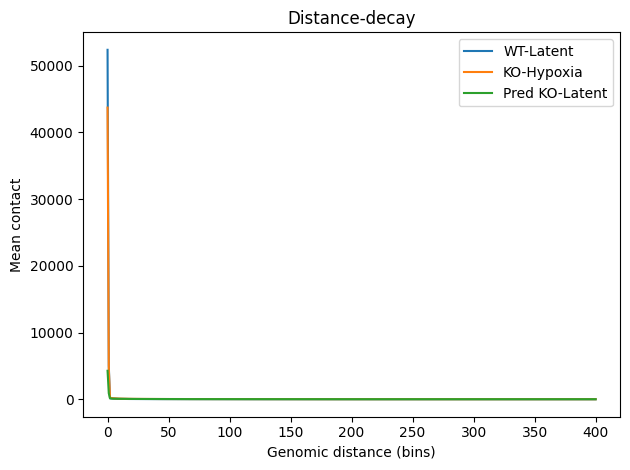

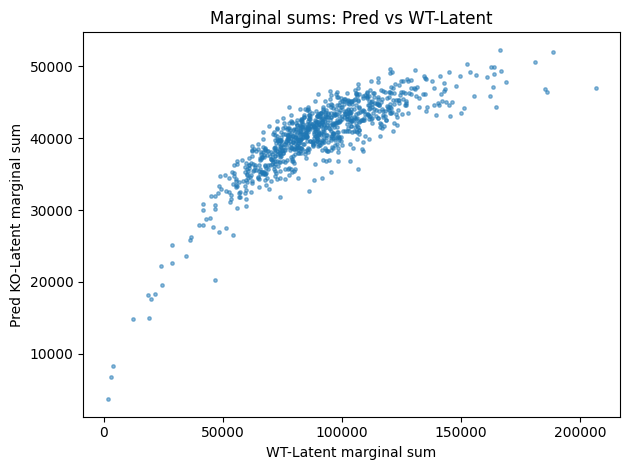

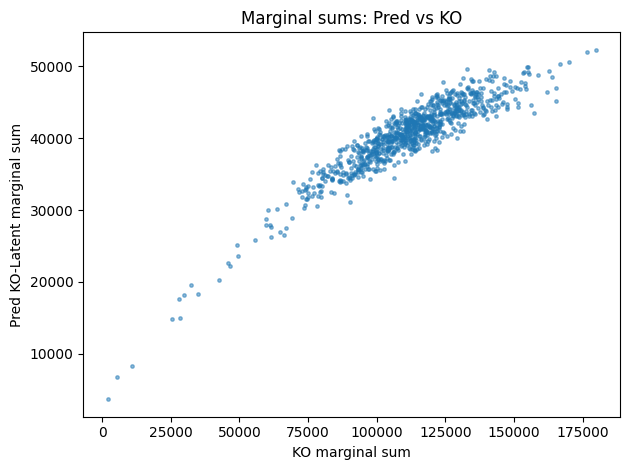

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


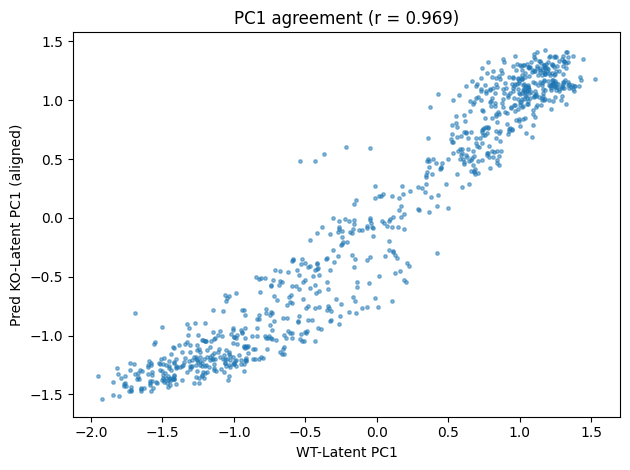

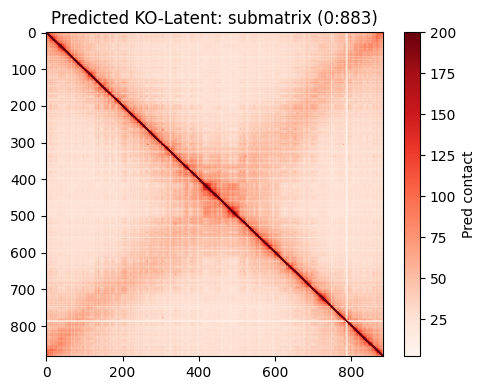

SVD LOCO-CV RMSE by rank: {1: 0.5321850747420156, 2: 0.5375912550292391, 3: 0.538835506074448}
Chosen rank: 1
Predicted file saved to: ./matrix_pdb/napm_ko-latent_5k.matrix


In [16]:
# Jupyter-ready: Predict KO-Latent Hi-C matrix (5 kb), save .matrix, and run quick QC + visualizations
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -------- Utility functions --------
def read_matrix_to_dense(path, n_bins):
    df = pd.read_csv(path, sep="\t", header=None, names=["i","j","v"])
    M = np.zeros((n_bins, n_bins), dtype=float)
    I = df["i"].values - 1
    J = df["j"].values - 1
    V = df["v"].values.astype(float)
    M[I, J] = V
    M[J, I] = V
    return M

def upper_tri_to_vec(M):
    idx = np.triu_indices_from(M)
    return M[idx], idx

def vec_to_upper_tri(vec, shape, idx):
    M = np.zeros(shape, dtype=float)
    M[idx] = vec
    i, j = idx
    M[j, i] = vec
    return M

def svd_feature_impute_fixed(Y, F, F_target, rank=1):
    col_mean = Y.mean(axis=0, keepdims=True)
    Yc = Y - col_mean
    U, s, VT = np.linalg.svd(Yc, full_matrices=False)
    U_k = U[:, :rank]
    S_k = np.diag(s[:rank])
    V_k = VT[:rank, :].T              # (conditions x rank)
    Z = V_k @ S_k                     # (conditions x rank)
    alpha = 1.0
    W = np.linalg.solve(F.T @ F + alpha*np.eye(F.shape[1]), F.T @ Z)  # (P x rank)
    Z_star = F_target @ W            # (1 x rank)
    Y_star = U_k @ Z_star.T          # (features x 1); no extra S_k
    col_mean_star = col_mean.mean(axis=1, keepdims=True)
    return (Y_star + col_mean_star).ravel()

def loco_cv_svd_fixed(Y, F, ranks=(1,2,3)):
    out = {}
    for r in ranks:
        errs = []
        for i in range(F.shape[0]):
            keep = [j for j in range(F.shape[0]) if j != i]
            yhat = svd_feature_impute_fixed(Y[:, keep], F[keep, :], F[i:i+1, :], rank=r)
            errs.append(np.sqrt(np.mean((Y[:, i] - yhat)**2)))
        out[r] = float(np.mean(errs))
    return out

def infer_bins(path):
    df = pd.read_csv(path, sep="\t", header=None, names=["i","j","v"])
    return int(max(df["i"].max(), df["j"].max()))

def distance_decay(M, max_dist=None):
    # mean contact vs genomic distance (|i-j|)
    n = M.shape[0]
    if max_dist is None:
        max_dist = n-1
    dists = np.arange(0, max_dist+1)
    means = np.zeros_like(dists, dtype=float)
    for d in dists:
        if d == 0:
            vals = np.diag(M)
        else:
            vals = np.diag(M, k=d)
        if vals.size == 0:
            means[d] = np.nan
        else:
            means[d] = np.nanmean(vals)
    return dists, means

def rowcol_sums(M):
    r = np.nansum(M, axis=1)
    c = np.nansum(M, axis=0)
    return (r + c) / 2.0

def compartment_pc1(M, eps=1e-8):
    # Distance-normalize by dividing each diagonal by its mean (observed/expected-like), then correlation of rows
    n = M.shape[0]
    OE = M.copy().astype(float)
    for d in range(n):
        diag = np.diag(OE, k=d)
        if diag.size == 0:
            continue
        mu = np.nanmean(diag) + eps
        # divide corresponding diagonal by its mean
        i = np.arange(n-d)
        j = i + d
        OE[i, j] = OE[i, j] / mu
        OE[j, i] = OE[i, j]
    # z-score rows
    X = (OE - OE.mean(axis=1, keepdims=True)) / (OE.std(axis=1, ddof=1, keepdims=True) + eps)
    C = np.corrcoef(X)  # correlation matrix between bins
    # First eigenvector via PCA
    pca = PCA(n_components=1)
    pc1 = pca.fit_transform(C).ravel()
    # normalize sign to be comparable (arbitrary up to sign)
    pc1 = (pc1 - pc1.mean()) / (pc1.std(ddof=1) + eps)
    return pc1

# -------- Paths --------
p_wt  = "./matrix_pdb/wt_5k.matrix"
p_hyp = "./matrix_pdb/Hypoxia_5k.matrix"
p_lat = "./matrix_pdb/latent_5k.matrix"
p_ko  = "./matrix_pdb/napm_ko_5k.matrix"
p_koh = "./matrix_pdb/napm_ko-Hypoxia_5k.matrix"
out_pred = "./matrix_pdb/napm_ko-latent_5k.matrix"

# -------- Load, predict, save --------
n_bins = infer_bins(p_wt)

wt  = np.log1p(read_matrix_to_dense(p_wt,  n_bins))
hyp = np.log1p(read_matrix_to_dense(p_hyp, n_bins))
lat = np.log1p(read_matrix_to_dense(p_lat, n_bins))
ko  = np.log1p(read_matrix_to_dense(p_ko,  n_bins))
koh = np.log1p(read_matrix_to_dense(p_koh, n_bins))

Y_wt,  idx = upper_tri_to_vec(wt)
Y_hyp, _   = upper_tri_to_vec(hyp)
Y_lat, _   = upper_tri_to_vec(lat)
Y_ko,  _   = upper_tri_to_vec(ko)
Y_koh, _   = upper_tri_to_vec(koh)

Y = np.vstack([Y_wt, Y_hyp, Y_lat, Y_ko, Y_koh]).T

feat_rows = {
    "WT":            [1, 1, 0, 0, 0, 0],
    "WT-Hypoxia":    [1, 1, 1, 0, 1, 0],
    "WT-Latent":     [1, 1, 0, 1, 0, 1],
    "KO":            [1, 0, 0, 0, 0, 0],
    "KO-Hypoxia":    [1, 0, 1, 0, 0, 0],
    "KO-Latent":     [1, 0, 0, 1, 0, 0],
}
conds = ["WT","WT-Hypoxia","WT-Latent","KO","KO-Hypoxia"]
F = np.array([feat_rows[c] for c in conds])
F_target = np.array(feat_rows["KO-Latent"])[None, :]

svd_rmse = loco_cv_svd_fixed(Y, F, ranks=(1,2,3))
best_rank = min(svd_rmse, key=svd_rmse.get)

pred_vec_log = svd_feature_impute_fixed(Y, F, F_target, rank=best_rank)
pred_vec = np.expm1(pred_vec_log)
pred_vec[pred_vec < 0] = 0.0
pred_dense = vec_to_upper_tri(pred_vec, (n_bins, n_bins), idx)

# Save .matrix (1-based, upper triangle incl. diagonal)
with open(out_pred, "w") as f:
    for i in range(n_bins):
        for j in range(i, n_bins):
            v = int(np.rint(pred_dense[i, j]))
            f.write(f"{i+1}\t{j+1}\t{v}\n")

# -------- Quick QC & Visualizations --------

# 1) Distance-decay curves
d_pred, m_pred = distance_decay(pred_dense, max_dist=min(400, n_bins-1))
d_lat,  m_lat  = distance_decay(np.expm1(lat),  max_dist=min(400, n_bins-1))
d_koh,  m_koh  = distance_decay(np.expm1(koh),  max_dist=min(400, n_bins-1))

plt.figure()
plt.plot(d_lat,  m_lat,  label="WT-Latent")
plt.plot(d_koh,  m_koh,  label="KO-Hypoxia")
plt.plot(d_pred, m_pred, label="Pred KO-Latent")
plt.xlabel("Genomic distance (bins)")
plt.ylabel("Mean contact")
plt.title("Distance-decay")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Row/Column marginal sums: scatter vs WT-Latent 和 KO
s_pred = rowcol_sums(pred_dense)
s_lat  = rowcol_sums(np.expm1(lat))
s_ko   = rowcol_sums(np.expm1(ko))

plt.figure()
plt.scatter(s_lat, s_pred, s=6, alpha=0.5)
plt.xlabel("WT-Latent marginal sum")
plt.ylabel("Pred KO-Latent marginal sum")
plt.title("Marginal sums: Pred vs WT-Latent")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(s_ko, s_pred, s=6, alpha=0.5)
plt.xlabel("KO marginal sum")
plt.ylabel("Pred KO-Latent marginal sum")
plt.title("Marginal sums: Pred vs KO")
plt.tight_layout()
plt.show()

# 3) Compartment-like PC1 correlation
pc1_pred = compartment_pc1(pred_dense)
pc1_lat  = compartment_pc1(np.expm1(lat))
# align sign for comparability
sign = np.sign(np.corrcoef(pc1_pred, pc1_lat)[0,1])
pc1_pred_aligned = pc1_pred * (1 if sign == 0 else sign)
pc_corr = float(np.corrcoef(pc1_pred_aligned, pc1_lat)[0,1])

plt.figure()
plt.scatter(pc1_lat, pc1_pred_aligned, s=6, alpha=0.5)
plt.xlabel("WT-Latent PC1")
plt.ylabel("Pred KO-Latent PC1 (aligned)")
plt.title(f"PC1 agreement (r = {pc_corr:.3f})")
plt.tight_layout()
plt.show()

# 4) Heatmap preview (top-left 150x150)
k = 883
plt.figure(figsize=(5,4))
plt.imshow(pred_dense[:k, :k], aspect="auto", vmax=2e2, cmap='Reds')
plt.colorbar(label="Pred contact")
plt.title("Predicted KO-Latent: submatrix (0:883)")
plt.tight_layout()
plt.savefig("./predicted_KO-Latent_submatrix.pdf", dpi=300)
plt.show()

# 5) Print summary metrics
print("SVD LOCO-CV RMSE by rank:", svd_rmse)
print("Chosen rank:", best_rank)
print("Predicted file saved to:", out_pred)


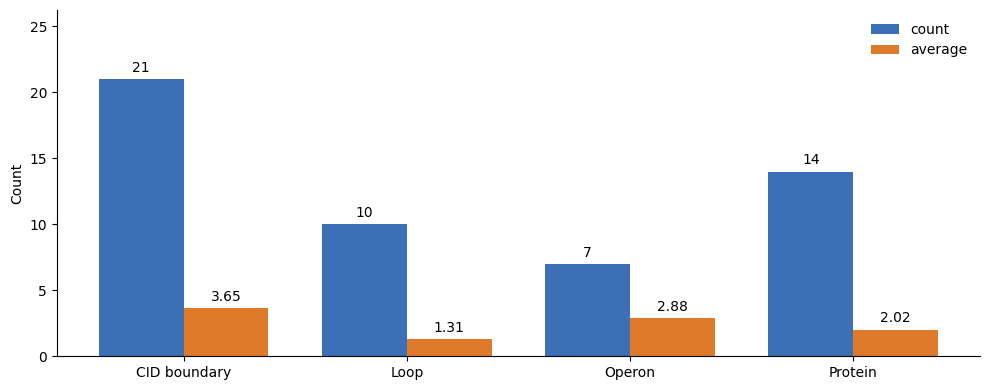

In [14]:
# Recreate the chart with new color palette, save as vector PDF with editable text
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Ensure text remains editable in PDF (not converted to paths)
matplotlib.rcParams["pdf.fonttype"] = 42   # TrueType
matplotlib.rcParams["ps.fonttype"] = 42    # TrueType

# Data
labels = ["CID boundary", "Loop", "Operon", "Protein"]
count = [21, 10, 7, 14]
average = [3.65, 1.31, 2.88, 2.02]

x = np.arange(len(labels))
width = 0.38

# Refreshed palette (legible in print; colorblind-friendly contrast)
color_count = "#3B6FB6"   # deep azure blue
color_avg   = "#E07A2B"   # warm amber

fig, ax = plt.subplots(figsize=(10, 4))

rects1 = ax.bar(x - width/2, count, width, label="count", color=color_count)
rects2 = ax.bar(x + width/2, average, width, label="average", color=color_avg)

ax.set_ylabel("Count")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(frameon=False)

# Annotate bars with values
def autolabel(rects, values, fmt="{:.0f}", dy=3):
    for rect, val in zip(rects, values):
        h = rect.get_height()
        ax.annotate(fmt.format(val),
                    xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, dy),
                    textcoords="offset points",
                    ha="center", va="bottom", fontsize=10)

autolabel(rects1, count, fmt="{:.0f}", dy=3)
autolabel(rects2, average, fmt="{:.2f}", dy=3)

ax.set_ylim(0, max(max(count), max(average)) * 1.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

pdf_path = "bar_dual_series_editable.pdf"
plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()

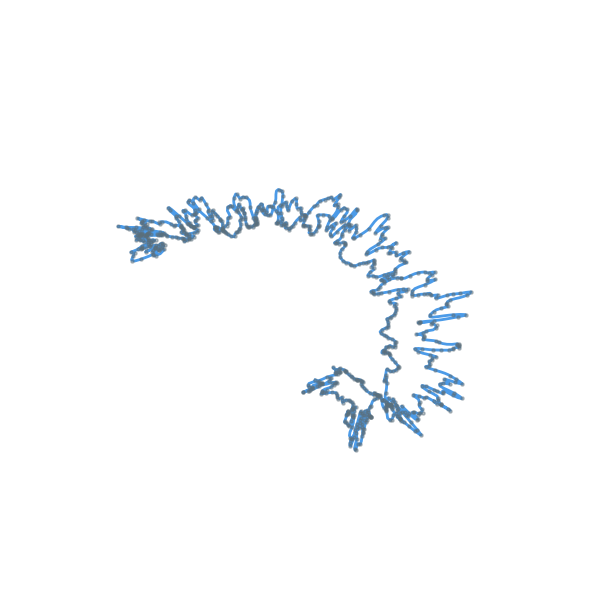

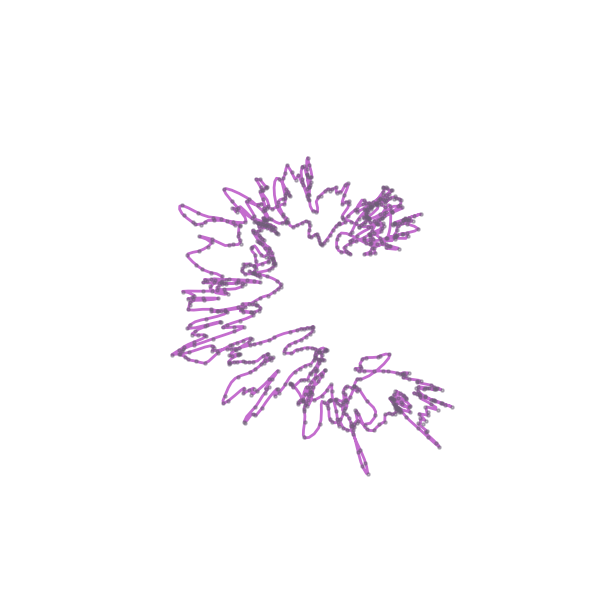

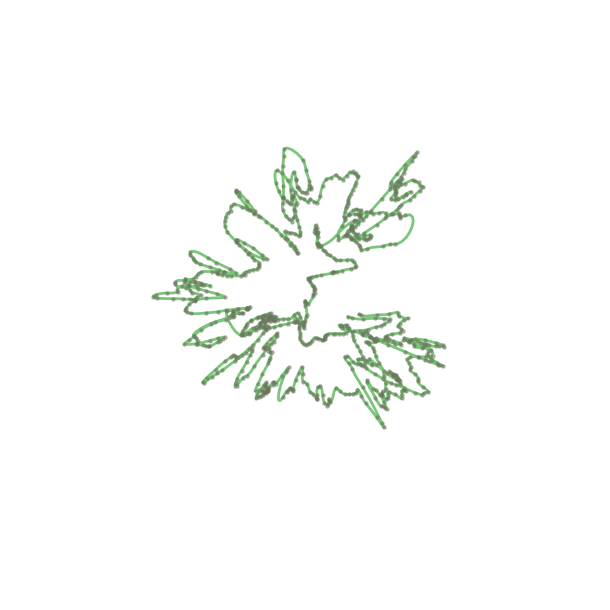

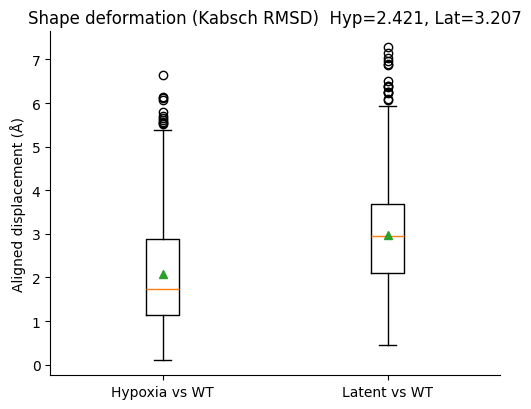

导出：
 - WT图： ./matrix_pdb/pdb_scatter_spline/wt_scatter_spline.pdf
 - Hypoxia图： ./matrix_pdb/pdb_scatter_spline/hypoxia_scatter_spline.pdf
 - Latent图： ./matrix_pdb/pdb_scatter_spline/latent_scatter_spline.pdf
 - 形变箱线图： ./matrix_pdb/pdb_scatter_spline/deformation_boxplot.pdf
 - 逐点位移： ./matrix_pdb/pdb_scatter_spline/deformation_per_point.csv
 - 总结： ./matrix_pdb/pdb_scatter_spline/deformation_summary.txt


In [17]:
# ========== 3D散点+丝滑线可视化 & 形变量比较（WT基准） ==========
# 依赖：numpy, matplotlib, scipy（用于B样条）, pandas
import os, numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.interpolate import splprep, splev

# —— PDF文本可编辑 —— #
matplotlib.rcParams["pdf.fonttype"] = 42  # TrueType
matplotlib.rcParams["ps.fonttype"]  = 42  # TrueType

# ---------- 路径（按需修改） ----------
p_wt   = "./matrix_pdb/wt_5k_1701486311672.pdb"
p_hyp  = "./matrix_pdb/wt-hypoxia_5k_1704962916426.pdb"
p_lat  = "./matrix_pdb/wt-latent_5k_1704965200849.pdb"
outdir = "./matrix_pdb/pdb_scatter_spline"
os.makedirs(outdir, exist_ok=True)

# ---------- 基础函数 ----------
def read_pdb_coords(path):
    """解析PDB中的ATOM/HETATM坐标，返回(N,3)数组（按文件原顺序）。"""
    xs, ys, zs = [], [], []
    with open(path, "r") as f:
        for line in f:
            rec = line[:6].strip()
            if rec in ("ATOM", "HETATM"):
                try:
                    x = float(line[30:38]); y = float(line[38:46]); z = float(line[46:54])
                    xs.append(x); ys.append(y); zs.append(z)
                except ValueError:
                    # 非坐标行或格式异常则跳过
                    continue
    return np.column_stack([xs, ys, zs]).astype(float)

def center(X):
    c = X.mean(axis=0, keepdims=True)
    return X - c, c

def kabsch_align(P, Q):
    """将Q最优刚体对齐到P（形状均为N×3）。返回 Q_aln, RMSD, R, t。"""
    P_c, Pc = center(P)
    Q_c, Qc = center(Q)
    C = Q_c.T @ P_c
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    D = np.diag([1, 1, d])
    R = V @ D @ Wt
    Q_rot = Q_c @ R
    t = Pc - Q_rot.mean(axis=0, keepdims=True)
    Q_aln = Q_rot + t
    rmsd = np.sqrt(np.mean(np.sum((P - Q_aln)**2, axis=1)))
    return Q_aln, float(rmsd), R, t

def silky_spline(X, smooth=0.0, n_pts=1200):
    """对点序列拟合B样条并高密度采样，得到顺滑“丝滑线条”"""
    tck, u = splprep([X[:,0], X[:,1], X[:,2]], s=smooth, k=3)
    u_fine = np.linspace(0, 1, n_pts)
    x_s, y_s, z_s = splev(u_fine, tck)
    return np.array([x_s, y_s, z_s]).T

def plot_scatter_with_spline(X, out_png, point_size=5, line_w=2.0,
                             color_pts="#5C6F7B", color_line="#4C9BE8"):
    """3D散点+丝滑线，隐藏坐标轴，并导出PNG/PDF（PDF文字可编辑）。"""
    fig = plt.figure(figsize=(6.2,6.2))
    ax  = fig.add_subplot(111, projection="3d")

    # 散点
    ax.scatter(X[:,0], X[:,1], X[:,2], s=point_size, alpha=0.45,
               depthshade=False, color=color_pts)

    # 丝滑线
    S = silky_spline(X, smooth=0.0, n_pts=1200)
    ax.plot(S[:,0], S[:,1], S[:,2], linewidth=2.0, color=color_line)

    # 去坐标轴/网格/面板
    ax.set_axis_off(); ax.grid(False)
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis.set_pane_color((1,1,1,0))
        axis.line.set_color((1,1,1,0))

    # 等比例视域
    max_range = (X.max(axis=0) - X.min(axis=0)).max()
    Xc = X.mean(axis=0)
    ax.set_xlim((Xc[0]-max_range/2, Xc[0]+max_range/2))
    ax.set_ylim((Xc[1]-max_range/2, Xc[1]+max_range/2))
    ax.set_zlim((Xc[2]-max_range/2, Xc[2]+max_range/2))

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_png.replace(".png",".pdf"), format="pdf", bbox_inches="tight")
    plt.show()
    return out_png, out_png.replace(".png",".pdf")

# ---------- 读取数据 ----------
WT  = read_pdb_coords(p_wt)
HYP = read_pdb_coords(p_hyp)
LAT = read_pdb_coords(p_lat)

# ---------- 可视化（无坐标系） ----------
png_wt  = os.path.join(outdir, "wt_scatter_spline.png")
png_hyp = os.path.join(outdir, "hypoxia_scatter_spline.png")
png_lat = os.path.join(outdir, "latent_scatter_spline.png")

plot_scatter_with_spline(WT,  png_wt,  color_pts="#5C6F7B", color_line="#4C9BE8")
plot_scatter_with_spline(HYP, png_hyp, color_pts="#6D5E76", color_line="#C46DCE")
plot_scatter_with_spline(LAT, png_lat, color_pts="#6B745C", color_line="#7BC67B")

# ---------- 形变量比较：Hypoxia/Latent 相对 WT ----------
# 刚体对齐（Kabsch）后计算RMSD与逐点位移
HYP_aln, rmsd_hyp, _, _ = kabsch_align(WT, HYP)
LAT_aln, rmsd_lat, _, _ = kabsch_align(WT, LAT)

disp_hyp = np.linalg.norm(WT - HYP_aln, axis=1)
disp_lat = np.linalg.norm(WT - LAT_aln, axis=1)

# 导出逐点位移
df_disp = pd.DataFrame({
    "index": np.arange(1, WT.shape[0]+1),
    "disp_hypoxia": disp_hyp,
    "disp_latent":  disp_lat
})
csv_path = os.path.join(outdir, "deformation_per_point.csv")
df_disp.to_csv(csv_path, index=False)

# 简明可视化（箱线图 + 均值）
fig, ax = plt.subplots(figsize=(5.2,4.2))
ax.boxplot([disp_hyp, disp_lat], labels=["Hypoxia vs WT", "Latent vs WT"], showmeans=True)
ax.set_ylabel("Aligned displacement (Å)")
ax.set_title(f"Shape deformation (Kabsch RMSD)  Hyp={rmsd_hyp:.3f}, Lat={rmsd_lat:.3f}")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
box_pdf = os.path.join(outdir, "deformation_boxplot.pdf")
plt.savefig(box_pdf, format="pdf", bbox_inches="tight")
plt.show()

# 保存简要总结
summary_txt = os.path.join(outdir, "deformation_summary.txt")
with open(summary_txt, "w") as f:
    f.write(f"Kabsch RMSD (Hypoxia vs WT): {rmsd_hyp:.6f}\n")
    f.write(f"Kabsch RMSD (Latent  vs WT): {rmsd_lat:.6f}\n")
    f.write(f"Per-point displacement CSV: {csv_path}\n")

print("导出：")
print(" - WT图：", png_wt.replace(".png",".pdf"))
print(" - Hypoxia图：", png_hyp.replace(".png",".pdf"))
print(" - Latent图：", png_lat.replace(".png",".pdf"))
print(" - 形变箱线图：", box_pdf)
print(" - 逐点位移：", csv_path)
print(" - 总结：", summary_txt)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


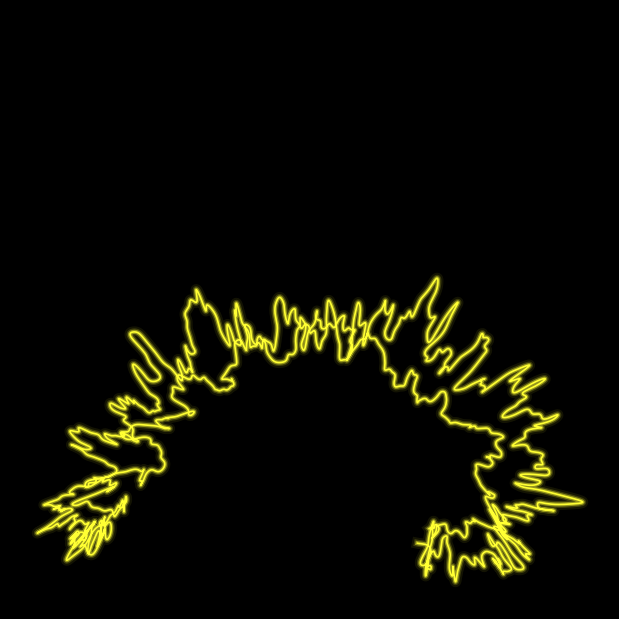

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


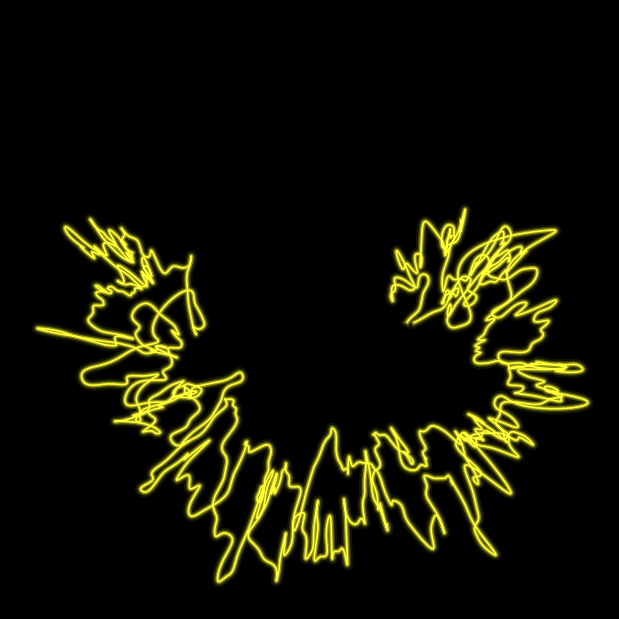

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


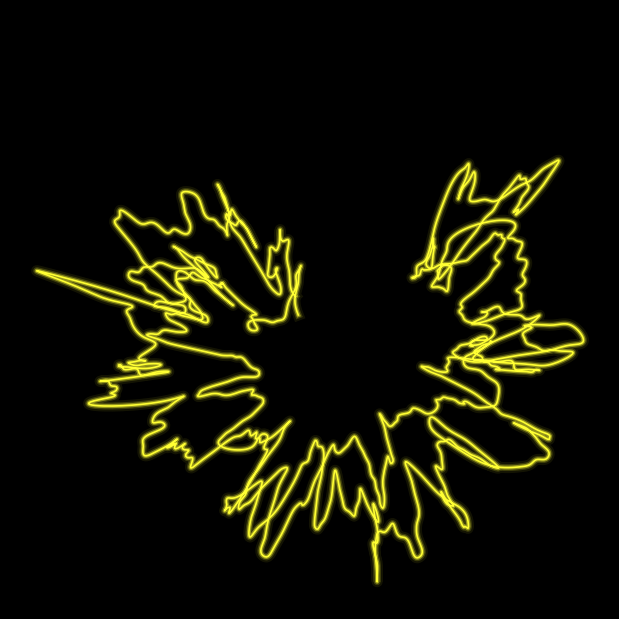

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


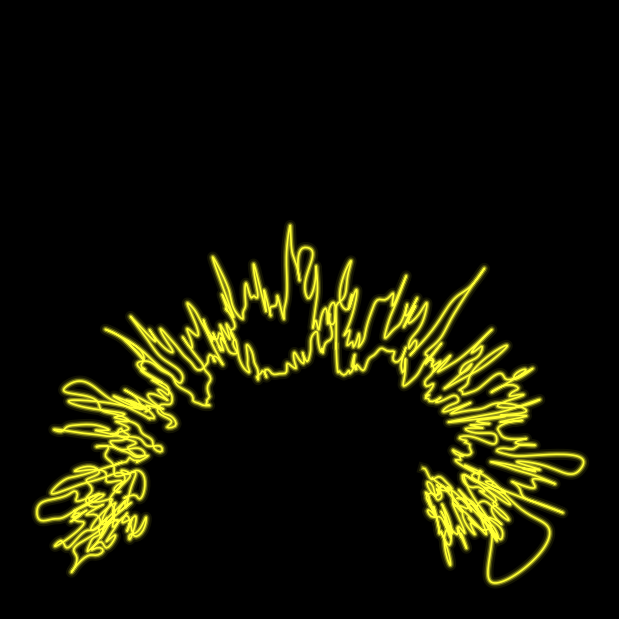

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


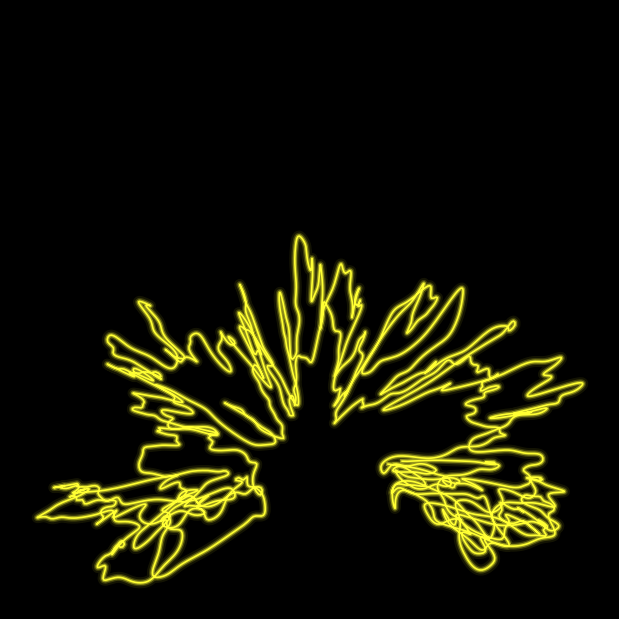

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


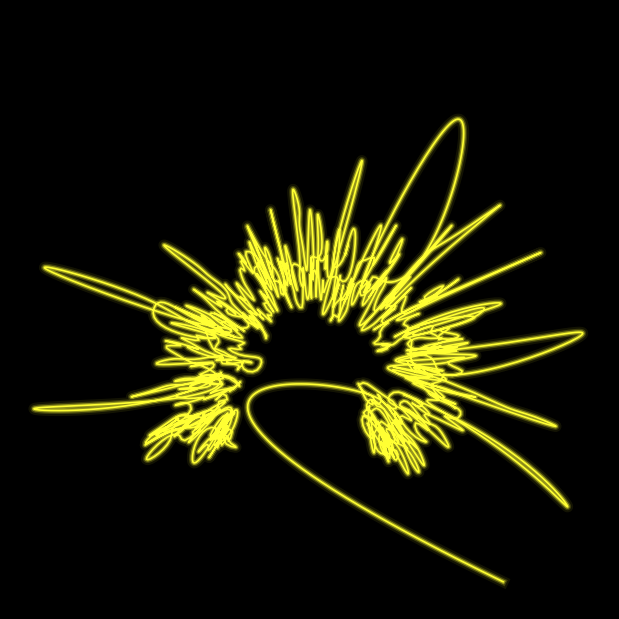

In [20]:
# —— 黑底荧光风格 PDF（3D->2D 投影 + 点云 + 多重描边发光）——
import os, numpy as np, matplotlib, matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.interpolate import splprep, splev

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"]  = 42

def read_pdb_coords(path):
    xs, ys, zs = [], [], []
    with open(path, "r") as f:
        for line in f:
            if line[:6].strip() in ("ATOM", "HETATM"):
                try:
                    xs.append(float(line[30:38]))
                    ys.append(float(line[38:46]))
                    zs.append(float(line[46:54]))
                except ValueError:
                    pass
    return np.column_stack([xs, ys, zs]).astype(float)

def principal_projection(X3):
    p = PCA(n_components=2).fit_transform(X3)
    mins, maxs = p.min(axis=0), p.max(axis=0)
    rng = (maxs - mins).max()
    return (p - mins) / (rng + 1e-9)

def silky_path_2d(P2, n_pts=4000, smooth=0.0):
    tck, _ = splprep([P2[:,0], P2[:,1]], s=smooth, k=3)
    u = np.linspace(0, 1, n_pts)
    x_s, y_s = splev(u, tck)
    return np.column_stack([x_s, y_s])

def neon_plot(P2, path2, out_pdf, dpi=300,
              bg="#000000", fg="#FFFF33",
              dot_alpha=0.10, dot_size=0.15,
              line_widths=(8.0, 5.0, 3.0, 1.2),
              line_alphas=(0.08, 0.18, 0.45, 1.0)):
    fig = plt.figure(figsize=(12, 6.0), facecolor=bg)
    ax = fig.add_subplot(111); ax.set_facecolor(bg); ax.set_aspect("equal", adjustable="box")
    # 星尘点云
    ax.scatter(P2[:,0], P2[:,1], s=dot_size, c=fg, alpha=dot_alpha, linewidths=0)
    # 发光描边（从粗到细）
    for lw, a in zip(line_widths, line_alphas):
        ax.plot(path2[:,0], path2[:,1], color=fg, lw=lw, alpha=a, solid_joinstyle="round")
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05); ax.axis("off")
    plt.tight_layout(pad=0)
    plt.savefig(out_pdf, format="pdf", dpi=dpi, facecolor=bg, edgecolor=bg, bbox_inches="tight")
    plt.show()

# 使用示例（替换为你的路径）
p_wt   = "./matrix_pdb/wt_5k_1701486311672.pdb"
p_hyp  = "./matrix_pdb/wt-hypoxia_5k_1704962916426.pdb"
p_lat  = "./matrix_pdb/wt-latent_5k_1704965200849.pdb"
p_ko   = "./matrix_pdb/napm_ko_5k_1704965399048.pdb"
p_ko_hyp = "./matrix_pdb/napm_ko-hypoxia_5k_1704965648139.pdb"
p_ko_lat = "./matrix_pdb/napm_ko-latent_5k_1756880967949.pdb"
outdir = "./matrix_pdb/fig_neon"; os.makedirs(outdir, exist_ok=True)

for name, p in [("wt", p_wt), ("hypoxia", p_hyp), ("latent", p_lat), 
                ("ko", p_ko), ("ko-hyp", p_ko_hyp), ("ko-lat", p_ko_lat)]:
    X  = read_pdb_coords(p)
    P2 = principal_projection(X)
    path2 = silky_path_2d(P2, n_pts=4000, smooth=0.0)  # smooth>0 可更顺滑
    neon_plot(P2, path2, os.path.join(outdir, f"{name}_neon.pdf"))


In [21]:
import os, numpy as np, pandas as pd

# 已有的 pdb 文件路径
p_wt     = "./matrix_pdb/wt_5k_1701486311672.pdb"
p_hyp    = "./matrix_pdb/wt-hypoxia_5k_1704962916426.pdb"
p_lat    = "./matrix_pdb/wt-latent_5k_1704965200849.pdb"
p_ko     = "./matrix_pdb/napm_ko_5k_1704965399048.pdb"
p_ko_hyp = "./matrix_pdb/napm_ko-hypoxia_5k_1704965648139.pdb"
p_ko_lat = "./matrix_pdb/napm_ko-latent_5k_1756880967949.pdb"

outdir = "./matrix_pdb/pairwise_disp"
os.makedirs(outdir, exist_ok=True)

# --- 工具函数 ---
def read_pdb_coords(path):
    xs, ys, zs = [], [], []
    with open(path) as f:
        for line in f:
            if line[:6].strip() in ("ATOM","HETATM"):
                try:
                    xs.append(float(line[30:38]))
                    ys.append(float(line[38:46]))
                    zs.append(float(line[46:54]))
                except ValueError:
                    pass
    return np.column_stack([xs,ys,zs]).astype(float)

def kabsch_align(P, Q):
    Pc = P - P.mean(0, keepdims=True)
    Qc = Q - Q.mean(0, keepdims=True)
    C = Qc.T @ Pc
    V, S, Wt = np.linalg.svd(C)
    d = np.sign(np.linalg.det(V @ Wt))
    D = np.diag([1,1,d])
    R = V @ D @ Wt
    Q_rot = Qc @ R
    t = P.mean(0, keepdims=True) - Q_rot.mean(0, keepdims=True)
    Q_aln = Q_rot + t
    rmsd = np.sqrt(np.mean(np.sum((P - Q_aln)**2, axis=1)))
    return Q_aln, rmsd

# --- 载入数据 ---
WT     = read_pdb_coords(p_wt)
HYP    = read_pdb_coords(p_hyp)
LAT    = read_pdb_coords(p_lat)
KO     = read_pdb_coords(p_ko)
KO_HYP = read_pdb_coords(p_ko_hyp)
KO_LAT = read_pdb_coords(p_ko_lat)

# --- 分组比较 ---
comparisons = [
    ("WT", "Hypoxia", WT, HYP),
    ("WT", "Latent",  WT, LAT),
    ("KO", "KO-Hypoxia", KO, KO_HYP),
    ("KO", "KO-Latent",  KO, KO_LAT),
]

rows = []
for ref_name, comp_name, A, B in comparisons:
    B_aln, rmsd = kabsch_align(A, B)
    disp = np.linalg.norm(A - B_aln, axis=1)
    # 保存逐点结果
    df = pd.DataFrame({
        "index": np.arange(1, len(A)+1),
        "displacement": disp
    })
    out_csv = os.path.join(outdir, f"disp_{comp_name}_vs_{ref_name}.csv")
    df.to_csv(out_csv, index=False)
    # 收集整体结果
    rows.append({"reference": ref_name, "condition": comp_name,
                 "RMSD": rmsd, "mean_disp": disp.mean(), "max_disp": disp.max(),
                 "csv": out_csv})

summary = pd.DataFrame(rows)
summary_out = os.path.join(outdir, "summary_disp.csv")
summary.to_csv(summary_out, index=False)

print("逐点位移文件：", [r["csv"] for r in rows])
print("汇总表：", summary_out)
print(summary)


逐点位移文件： ['./matrix_pdb/pairwise_disp/disp_Hypoxia_vs_WT.csv', './matrix_pdb/pairwise_disp/disp_Latent_vs_WT.csv', './matrix_pdb/pairwise_disp/disp_KO-Hypoxia_vs_KO.csv', './matrix_pdb/pairwise_disp/disp_KO-Latent_vs_KO.csv']
汇总表： ./matrix_pdb/pairwise_disp/summary_disp.csv
  reference   condition      RMSD  mean_disp  max_disp  \
0        WT     Hypoxia  2.420570   2.083986  6.649663   
1        WT      Latent  3.206614   2.977406  7.284770   
2        KO  KO-Hypoxia  3.143488   2.715835  8.766629   
3        KO   KO-Latent  5.795902   5.604905  9.205305   

                                                 csv  
0  ./matrix_pdb/pairwise_disp/disp_Hypoxia_vs_WT.csv  
1   ./matrix_pdb/pairwise_disp/disp_Latent_vs_WT.csv  
2  ./matrix_pdb/pairwise_disp/disp_KO-Hypoxia_vs_...  
3  ./matrix_pdb/pairwise_disp/disp_KO-Latent_vs_K...  


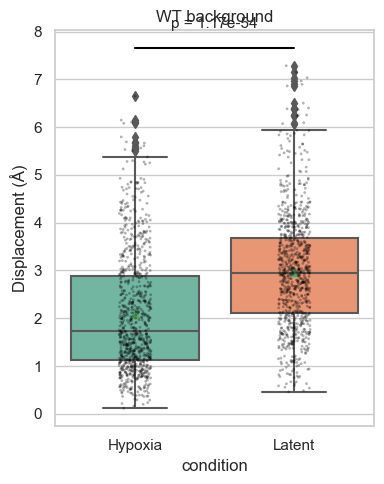

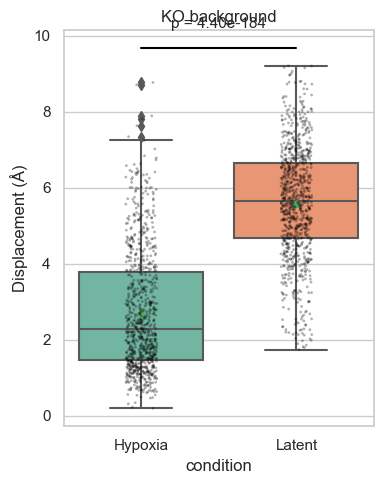

p-value (WT group): 1.1727366330670824e-54
p-value (KO group): 4.402558620496036e-184


In [24]:
import os, numpy as np, pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind

outdir = "./matrix_pdb/pairwise_disp"

# 逐点结果文件
files = {
    "WT": {
        "Hypoxia": os.path.join(outdir, "disp_Hypoxia_vs_WT.csv"),
        "Latent":  os.path.join(outdir, "disp_Latent_vs_WT.csv"),
    },
    "KO": {
        "Hypoxia": os.path.join(outdir, "disp_KO-Hypoxia_vs_KO.csv"),
        "Latent":  os.path.join(outdir, "disp_KO-Latent_vs_KO.csv"),
    }
}

# 合并成长表
rows = []
for group, conds in files.items():
    for cond, path in conds.items():
        df = pd.read_csv(path)
        df["group"] = group
        df["condition"] = cond
        rows.append(df)
df_all = pd.concat(rows, ignore_index=True)

# --- 绘制 boxplot + 计算 p 值 ---
sns.set(style="whitegrid")

def plot_box(group, out_png):
    df_sub = df_all[df_all["group"] == group]
    plt.figure(figsize=(4,5))
    ax = sns.boxplot(data=df_sub, x="condition", y="displacement",
                     palette="Set2", showmeans=True)
    sns.stripplot(data=df_sub, x="condition", y="displacement",
                  color="black", size=2, alpha=0.3)

    # 计算 p 值
    vals1 = df_sub[df_sub["condition"]=="Hypoxia"]["displacement"]
    vals2 = df_sub[df_sub["condition"]=="Latent"]["displacement"]
    stat, p = mannwhitneyu(vals1, vals2, alternative="two-sided")

    # 添加显著性标注
    y_max = max(df_sub["displacement"])
    ax.plot([0,1],[y_max*1.05,y_max*1.05], color="black")
    ax.text(0.5, y_max*1.1, f"p = {p:.2e}", ha="center", va="bottom", fontsize=11)

    ax.set_title(f"{group} background")
    ax.set_ylabel("Displacement (Å)")
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.show()
    return p

p_wt = plot_box("WT", os.path.join(outdir,"boxplot_WT.pdf"))
p_ko = plot_box("KO", os.path.join(outdir,"boxplot_KO.pdf"))

print("p-value (WT group):", p_wt)
print("p-value (KO group):", p_ko)


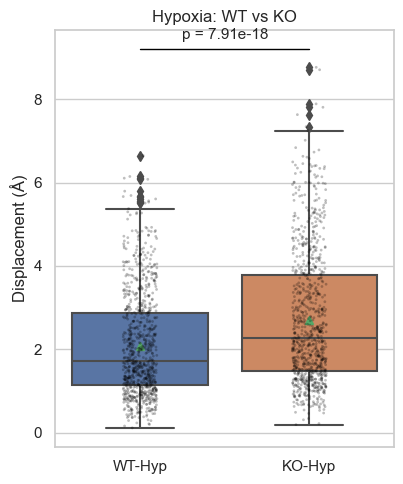

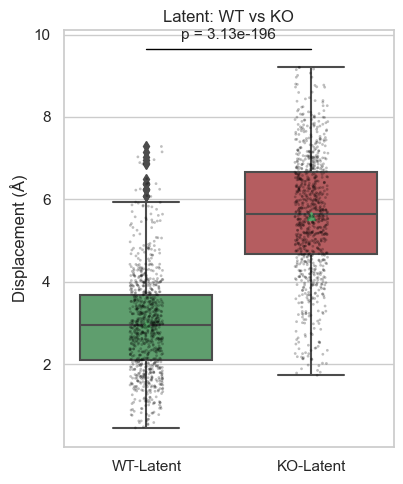

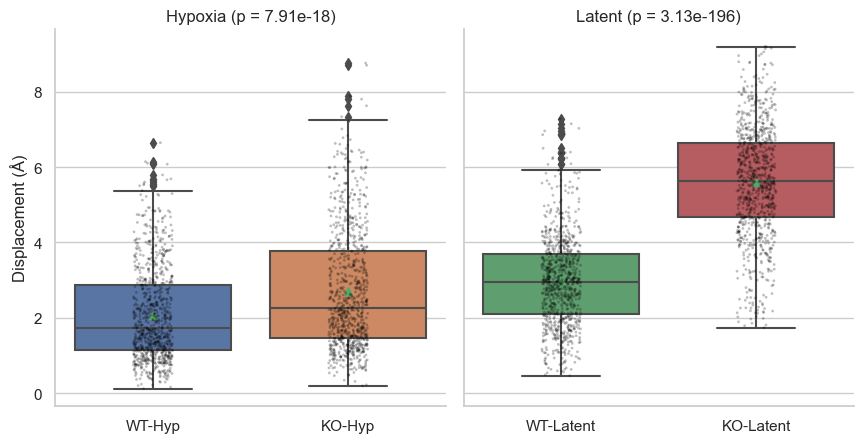

导出：
 - ./matrix_pdb/pairwise_disp/box_hypoxia_WT_vs_KO.pdf
 - ./matrix_pdb/pairwise_disp/box_latent_WT_vs_KO.pdf
 - ./matrix_pdb/pairwise_disp/box_WTvsKO_hyp_lat_combined.pdf
Hypoxia p = 7.915e-18 | Latent p = 3.134e-196


In [23]:
# === Seaborn boxplot：WT-Hyp vs KO-Hyp；WT-Latent vs KO-Latent（含p值） ===
import os, numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# 让PDF中文字可编辑
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"]  = 42

# 逐点位移CSV所在目录（沿用前面导出的）
indir = "./matrix_pdb/pairwise_disp"
paths = {
    "WT-Hypoxia_vs_WT":      os.path.join(indir, "disp_Hypoxia_vs_WT.csv"),
    "WT-Latent_vs_WT":       os.path.join(indir, "disp_Latent_vs_WT.csv"),
    "KO-Hypoxia_vs_KO":      os.path.join(indir, "disp_KO-Hypoxia_vs_KO.csv"),
    "KO-Latent_vs_KO":       os.path.join(indir, "disp_KO-Latent_vs_KO.csv"),
}
for k, p in paths.items():
    if not os.path.exists(p):
        raise FileNotFoundError(f"缺少文件：{k} -> {p}\n请先运行两两位移导出脚本。")

# 读取数据
df_wt_hyp  = pd.read_csv(paths["WT-Hypoxia_vs_WT"])      .rename(columns={"displacement":"WT-Hypoxia_vs_WT"})
df_wt_lat  = pd.read_csv(paths["WT-Latent_vs_WT"])       .rename(columns={"displacement":"WT-Latent_vs_WT"})
df_ko_hyp  = pd.read_csv(paths["KO-Hypoxia_vs_KO"])      .rename(columns={"displacement":"KO-Hypoxia_vs_KO"})
df_ko_lat  = pd.read_csv(paths["KO-Latent_vs_KO"])       .rename(columns={"displacement":"KO-Latent_vs_KO"})

# 合并成长表，便于作图
def melt_with_label(df, col_name, label_left, label_right):
    return pd.DataFrame({
        "index": df["index"].values,
        "displacement": df[col_name].values,
        "label": [label_left if "WT-" in col_name else label_right]*len(df)
    })

long_hyp = pd.concat([
    melt_with_label(df_wt_hyp, "WT-Hypoxia_vs_WT", "WT-Hyp", "KO-Hyp"), 
    melt_with_label(df_ko_hyp, "KO-Hypoxia_vs_KO", "WT-Hyp", "KO-Hyp")],
    ignore_index=True)

long_lat = pd.concat([
    melt_with_label(df_wt_lat, "WT-Latent_vs_WT", "WT-Latent", "KO-Latent"),
    melt_with_label(df_ko_lat, "KO-Latent_vs_KO", "WT-Latent", "KO-Latent")],
    ignore_index=True)

# 统计检验（Mann–Whitney U）
def pvalue_mwu(df, left_label, right_label):
    a = df[df["label"]==left_label]["displacement"].values
    b = df[df["label"]==right_label]["displacement"].values
    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    return p, a, b

p_hyp, a_hyp, b_hyp = pvalue_mwu(long_hyp, "WT-Hyp", "KO-Hyp")
p_lat, a_lat, b_lat = pvalue_mwu(long_lat, "WT-Latent", "KO-Latent")

# 画图函数（带p值横线）
def box_with_p(df, order, title, outpath, palette=("C0","C1")):
    sns.set(style="whitegrid")
    plt.figure(figsize=(4.2,5))
    ax = sns.boxplot(data=df, x="label", y="displacement",
                     order=order, palette=palette, showmeans=True)
    sns.stripplot(data=df, x="label", y="displacement", order=order,
                  color="black", size=2, alpha=0.25)
    # p值标注
    y_max = df["displacement"].max()
    y_min = df["displacement"].min()
    y = y_max + 0.05*(y_max - y_min)
    ax.plot([0,1],[y,y], color="black", lw=1)
    p = p_hyp if "Hyp" in title else p_lat
    ax.text(0.5, y + 0.02*(y_max - y_min), f"p = {p:.2e}", ha="center", va="bottom", fontsize=11)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Displacement (Å)")
    plt.tight_layout()
    # 同时出 PNG + PDF
    plt.savefig(outpath.replace(".pdf",".png"), dpi=300)
    plt.savefig(outpath, format="pdf", bbox_inches="tight")
    plt.show()

outdir = indir  # 直接存在同一个目录下
box_with_p(long_hyp, ["WT-Hyp","KO-Hyp"], "Hypoxia: WT vs KO",
           os.path.join(outdir, "box_hypoxia_WT_vs_KO.pdf"),
           palette=("#4C72B0","#DD8452"))
box_with_p(long_lat, ["WT-Latent","KO-Latent"], "Latent: WT vs KO",
           os.path.join(outdir, "box_latent_WT_vs_KO.pdf"),
           palette=("#55A868","#C44E52"))

# 也做一个并排合成图（统一y轴）
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(8.8,4.6), sharey=True)
sns.boxplot(ax=axes[0], data=long_hyp, x="label", y="displacement",
            order=["WT-Hyp","KO-Hyp"], palette=("#4C72B0","#DD8452"), showmeans=True)
sns.stripplot(ax=axes[0], data=long_hyp, x="label", y="displacement",
              order=["WT-Hyp","KO-Hyp"], color="black", size=2, alpha=0.25)
axes[0].set_title(f"Hypoxia (p = {p_hyp:.2e})")
axes[0].set_xlabel(""); axes[0].set_ylabel("Displacement (Å)")

sns.boxplot(ax=axes[1], data=long_lat, x="label", y="displacement",
            order=["WT-Latent","KO-Latent"], palette=("#55A868","#C44E52"), showmeans=True)
sns.stripplot(ax=axes[1], data=long_lat, x="label", y="displacement",
              order=["WT-Latent","KO-Latent"], color="black", size=2, alpha=0.25)
axes[1].set_title(f"Latent (p = {p_lat:.2e})")
axes[1].set_xlabel(""); axes[1].set_ylabel("")

for ax in axes:
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(outdir, "box_WTvsKO_hyp_lat_combined.png"), dpi=300)
plt.savefig(os.path.join(outdir, "box_WTvsKO_hyp_lat_combined.pdf"), format="pdf", bbox_inches="tight")
plt.show()

print("导出：")
print(" -", os.path.join(outdir, "box_hypoxia_WT_vs_KO.pdf"))
print(" -", os.path.join(outdir, "box_latent_WT_vs_KO.pdf"))
print(" -", os.path.join(outdir, "box_WTvsKO_hyp_lat_combined.pdf"))
print(f"Hypoxia p = {p_hyp:.3e} | Latent p = {p_lat:.3e}")
